In [3]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm, trange
import nltk
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('sp.csv')

In [5]:
data.shape

(81191, 5)

In [6]:
data.head(5)

,Название,Артикул,Категория,Цена без карты,Цена с картой
0,Вентилятор BORGE Подкровельный Viotto черепаха...,17162001,Строительные материалы,1 514.15 ₽,1 438.44 ₽
1,Лента вентиляционная ПВХ 10х500 см,18824701,Строительные материалы,554.63 ₽,526.90 ₽
2,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,Строительные материалы,329.33 ₽,312.86 ₽
3,Вентиляционная труба ОНДУВИЛЛА,19190801,Строительные материалы,4 099.00 ₽,3 894.05 ₽
4,Выход вентиляционный ТЕХНОНИКОЛЬ Изолированный...,19190601,Строительные материалы,3 799.00 ₽,3 609.05 ₽


In [7]:
topics = ['Строительные материалы','Инструменты и крепёж', 'Двери, окна, замки',
 'Обои', 'Напольные покрытия', 'Потолочные и стеновые покрытия',
 'Керамическая плитка', 'Краски, герметики, пропитки',
 'Инженерная электрика, лампы', 'Сауны и бани',
 'Интерьер, текстиль, камины, оформление окон, картины',
 'Хранение и порядок', 'Товары для дома, подарки, бытовая химия',
 'Кухни, мойки, смесители, бытовая техника',
 'Вентиляция, климатическое оборудование', 'Освещение',
 'Отопление, водоснабжение, канализация',
 'Сантехника, мебель для ванной комнаты', 'Туризм и отдых', 'Автотовары',
 'Сад и огород']
pack_in_cat = 3000

In [8]:
df_res = pd.DataFrame()

for topic in tqdm(topics):
    df_topic = data[data['Категория'] == topic][:pack_in_cat]
    df_res = df_res.append(df_topic, ignore_index=True)

In [9]:
df_res.shape

(49516, 5)

In [10]:
import string
def remove_punctuation(text):
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text):
    return ''.join([i if not i.isdigit() else ' ' for i in text])

import re
def remove_multiple_spaces(text):
	return re.sub(r'\s+', ' ', text, flags=re.I)

import nltk
nltk.download('stopwords')
from nltk.stem import *
from nltk.corpus import stopwords
from pymystem3 import Mystem
from string import punctuation
mystem = Mystem() 

russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...'])
def lemmatize_text(text):
    tokens = mystem.lemmatize(text.lower())
    tokens = [token for token in tokens if token not in russian_stopwords and token != " "]
    text = " ".join(tokens)
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mugichu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<ipython-input-11-4e4adeaa338a>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


<AxesSubplot:>

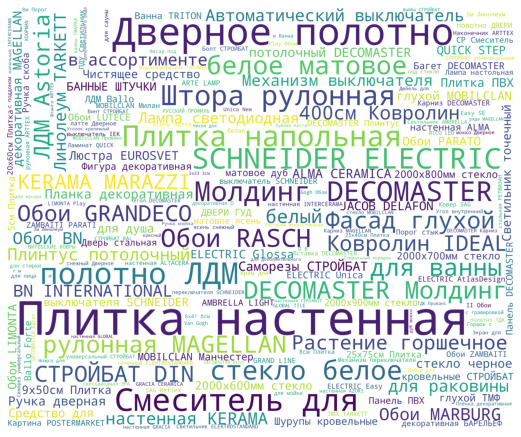

In [11]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus
# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus
# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',width=3000,height=2500,max_words=200,random_state=42).generate(str_corpus(corpus))
    return wordCloud

corpus = get_corpus(df_res['Название'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [12]:
prep_text = [remove_multiple_spaces(remove_numbers(remove_punctuation(text.lower()))) for text in tqdm(df_res['Название'])]


In [13]:
len(prep_text)
prep_text[1]

'лента вентиляционная пвх х см'

In [14]:
df_res['text_prep'] = prep_text
df_res.head(1)

,Название,Артикул,Категория,Цена без карты,Цена с картой,text_prep
0,Вентилятор BORGE Подкровельный Viotto черепаха...,17162001,Строительные материалы,1 514.15 ₽,1 438.44 ₽,вентилятор borge подкровельный viotto черепаха...


In [15]:
df_res.shape

(49516, 6)

In [16]:
df_res.head()

,Название,Артикул,Категория,Цена без карты,Цена с картой,text_prep
0,Вентилятор BORGE Подкровельный Viotto черепаха...,17162001,Строительные материалы,1 514.15 ₽,1 438.44 ₽,вентилятор borge подкровельный viotto черепаха...
1,Лента вентиляционная ПВХ 10х500 см,18824701,Строительные материалы,554.63 ₽,526.90 ₽,лента вентиляционная пвх х см
2,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,Строительные материалы,329.33 ₽,312.86 ₽,проходка borge кровельная d мм прямая №
3,Вентиляционная труба ОНДУВИЛЛА,19190801,Строительные материалы,4 099.00 ₽,3 894.05 ₽,вентиляционная труба ондувилла
4,Выход вентиляционный ТЕХНОНИКОЛЬ Изолированный...,19190601,Строительные материалы,3 799.00 ₽,3 609.05 ₽,выход вентиляционный технониколь изолированный...


In [17]:
from nltk.stem.snowball import SnowballStemmer 
stemmer = SnowballStemmer("russian")

In [18]:
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...', 'т.д.', 'т', 'д','Главная','Каталог'])

In [19]:
import nltk
nltk.download('punkt')
from nltk import word_tokenize
text = df_res['text_prep'][0]
word_tokenize(text)

[nltk_data] Downloading package punkt to /home/mugichu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['вентилятор', 'borge', 'подкровельный', 'viotto', 'черепаха', 'для', 'мч']

In [20]:
from nltk import word_tokenize

stemmed_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    stemmed_tokens = [stemmer.stem(token) for token in tokens if token not in russian_stopwords]
    text = " ".join(stemmed_tokens)
    stemmed_texts_list.append(text)

df_res['text_stem'] = stemmed_texts_list

In [21]:
from nltk import word_tokenize

sw_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    text = " ".join(tokens)
    sw_texts_list.append(text)

df_res['text_sw'] = sw_texts_list

In [22]:
def remove_stop_words(text):
    tokens = word_tokenize(text) 
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    return " ".join(tokens)

In [23]:
df_res['text_sw'][0]

'вентилятор borge подкровельный viotto черепаха мч'

In [24]:
df_res.to_csv('sp_stemmed.csv')

In [25]:
df_res['text_stem'][0]

'вентилятор borge подкровельн viotto черепах мч'

In [26]:
lemm_texts_list = []
for text in tqdm(df_res['text_sw']):
    #print(text)
    try:
        text_lem = mystem.lemmatize(text)
        tokens = [token for token in text_lem if token != ' ' and token not in russian_stopwords]
        text = " ".join(tokens)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df_res['text_lemm'] = lemm_texts_list

In [27]:
def lemmatize_text(text):
    text_lem = mystem.lemmatize(text)
    tokens = [token for token in text_lem if token != ' ']
    return " ".join(tokens)

In [28]:
df_res.to_csv('lemm.csv')

In [29]:
df_res = pd.read_csv('lemm.csv', encoding = 'utf-8')

In [30]:
df_res.head()

,Unnamed: 0,Название,Артикул,Категория,Цена без карты,Цена с картой,text_prep,text_stem,text_sw,text_lemm
0,0,Вентилятор BORGE Подкровельный Viotto черепаха...,17162001,Строительные материалы,1 514.15 ₽,1 438.44 ₽,вентилятор borge подкровельный viotto черепаха...,вентилятор borge подкровельн viotto черепах мч,вентилятор borge подкровельный viotto черепаха мч,вентилятор borge подкровельный viotto черепаха...
1,1,Лента вентиляционная ПВХ 10х500 см,18824701,Строительные материалы,554.63 ₽,526.90 ₽,лента вентиляционная пвх х см,лент вентиляцион пвх х см,лента вентиляционная пвх х см,лента вентиляционный пвх х см \n
2,2,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,Строительные материалы,329.33 ₽,312.86 ₽,проходка borge кровельная d мм прямая №,проходк borge кровельн d мм прям №,проходка borge кровельная d мм прямая №,проходка borge кровельный d мм прямой № \n
3,3,Вентиляционная труба ОНДУВИЛЛА,19190801,Строительные материалы,4 099.00 ₽,3 894.05 ₽,вентиляционная труба ондувилла,вентиляцион труб ондувилл,вентиляционная труба ондувилла,вентиляционный труба ондувилла \n
4,4,Выход вентиляционный ТЕХНОНИКОЛЬ Изолированный...,19190601,Строительные материалы,3 799.00 ₽,3 609.05 ₽,выход вентиляционный технониколь изолированный...,выход вентиляцион техноникол изолирова d мм,выход вентиляционный технониколь изолированный...,выход вентиляционный технониколь изолированный...


In [31]:
names = df_res['text_lemm']
type(names)

pandas.core.series.Series

<ipython-input-32-0a9cb79cad36>:8: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


<AxesSubplot:>

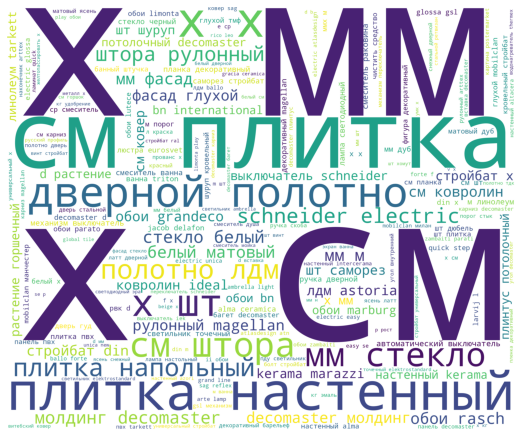

In [32]:
corpus = get_corpus(df_res['text_lemm'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [33]:
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer("russian")

def token_and_stem(text):
    tokens = [word for sent in nltk.sent_tokenize(text) for word in nltk.word_tokenize(sent)]
    filtered_tokens = []
    for token in tokens:
        if re.search('[а-яА-Я]', token):
            filtered_tokens.append(token)
    stems = [stemmer.stem(t) for t in filtered_tokens]
    return stems

In [34]:
stopwords = nltk.corpus.stopwords.words('russian')
#можно расширить список стоп-слов
stopwords.extend(['что', 'это', 'так', 'вот', 'быть', 'как', 'в', 'к', 'на', 'Главная', 'Каталог','\n'])

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

n_featur=200000
tfidf_vectorizer = TfidfVectorizer(max_df=0.8, max_features=10000,
                                 min_df=0.01, stop_words=stopwords,
                                 use_idf=True, tokenizer=token_and_stem, ngram_range=(1,3))

In [35]:
%%time
tfidf_matrix = tfidf_vectorizer.fit_transform(names)

/home/mugichu/anaconda3/lib/python3.8/site-packages/sklearn/feature_extraction/text.py:388: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['бол', 'больш', 'будт', 'быт', 'вед', 'впроч', 'всег', 'всегд', 'главн', 'даж', 'друг', 'е', 'ег', 'ем', 'есл', 'ест', 'ещ', 'зач', 'зде', 'ил', 'иногд', 'каталог', 'когд', 'конечн', 'куд', 'лучш', 'межд', 'мен', 'мног', 'мо', 'можн', 'нег', 'нельз', 'нибуд', 'никогд', 'нич', 'опя', 'посл', 'пот', 'почт', 'разв', 'сво', 'себ', 'совс', 'теб', 'тепер', 'тог', 'тогд', 'тож', 'тольк', 'хорош', 'хот', 'чег', 'чут', 'эт'] not in stop_words.
  warnings.warn('Your stop_words may be inconsistent with '


CPU times: user 13.9 s, sys: 0 ns, total: 13.9 s
Wall time: 13.9 s


In [36]:
type(tfidf_matrix)
tfidf_matrix

<49516x82 sparse matrix of type '<class 'numpy.float64'>'
	with 115207 stored elements in Compressed Sparse Row format>

In [37]:
print(tfidf_matrix.shape)

(49516, 82)


In [38]:
tfidf_matrix[:10]

<10x82 sparse matrix of type '<class 'numpy.float64'>'
	with 8 stored elements in Compressed Sparse Row format>

In [39]:
num_clusters = 21

# Метод к-средних - KMeans
from sklearn.cluster import KMeans
km = KMeans(n_clusters=num_clusters)

In [40]:
%%time
km.fit(tfidf_matrix)

CPU times: user 12.6 s, sys: 283 ms, total: 12.8 s
Wall time: 1.82 s


KMeans(n_clusters=21)

In [41]:
%%time
idx = km.fit(tfidf_matrix)
clusters = km.labels_.tolist()

#print(clusters)
#print (km.labels_)

CPU times: user 11.8 s, sys: 180 ms, total: 12 s
Wall time: 1.72 s


In [42]:
len(km.labels_)
clusters[:10]

[1, 7, 14, 1, 14, 1, 1, 1, 14, 1]

In [43]:
clusterkm = km.labels_.tolist()
frame = pd.DataFrame(names)

#k-means
out = { 'names': names, 'cluster': clusterkm, 'topic': df_res['Категория'] }
frame1 = pd.DataFrame(out, columns = ['names', 'cluster', 'topic'])

In [44]:
frame1

,names,cluster,topic
0,вентилятор borge подкровельный viotto черепаха...,1,Строительные материалы
1,лента вентиляционный пвх х см \n,7,Строительные материалы
2,проходка borge кровельный d мм прямой № \n,14,Строительные материалы
3,вентиляционный труба ондувилла \n,1,Строительные материалы
4,выход вентиляционный технониколь изолированный...,14,Строительные материалы
...,...,...,...
49511,горшок ливингрин альфа белый \n,1,Сад и огород
49512,набор горшок koopman шт х см \n,7,Сад и огород
49513,горшок martika колывань c t \n,1,Сад и огород
49514,вазон высокий мартик колывань терракотовый л \n,9,Сад и огород


In [46]:
fp = frame1[frame1.topic.eq('Строительные материалы') & frame1.cluster.eq(2)]
print(len(fp))

482


In [47]:
# MiniBatchKMeans
from sklearn.cluster import MiniBatchKMeans

mbk  = MiniBatchKMeans(init='random', n_clusters=num_clusters) #(init='k-means++', ‘random’ or an ndarray)
mbk.fit_transform(tfidf_matrix)
%time mbk.fit(tfidf_matrix)
miniclusters = mbk.labels_.tolist()
print (mbk.labels_)

CPU times: user 598 ms, sys: 19.9 ms, total: 618 ms
Wall time: 430 ms
[18 11 14 ... 18  0  0]


In [48]:
print(topic)
print(num_clusters)

Сад и огород
21


In [49]:
for topic in topics:
    print(topic, end = ' \t\t ')
    for cluster in range(num_clusters):
        print(cluster, ' : ', len(frame1[ frame1.topic.eq(topic) &  frame1.cluster.eq(cluster) ]), end = ' ')
    print()

Строительные материалы 		 0  :  1 1  :  913 2  :  482 3  :  0 4  :  0 5  :  23 6  :  0 7  :  19 8  :  0 9  :  27 10  :  152 11  :  2 12  :  163 13  :  0 14  :  248 15  :  0 16  :  0 17  :  0 18  :  5 19  :  0 20  :  0 
Инструменты и крепёж 		 0  :  0 1  :  483 2  :  157 3  :  0 4  :  0 5  :  1757 6  :  0 7  :  1 8  :  0 9  :  0 10  :  274 11  :  0 12  :  188 13  :  0 14  :  139 15  :  0 16  :  0 17  :  0 18  :  1 19  :  0 20  :  0 
Двери, окна, замки 		 0  :  0 1  :  1057 2  :  355 3  :  0 4  :  0 5  :  6 6  :  0 7  :  1 8  :  0 9  :  0 10  :  26 11  :  0 12  :  0 13  :  0 14  :  60 15  :  0 16  :  0 17  :  1422 18  :  6 19  :  67 20  :  0 
Обои 		 0  :  0 1  :  10 2  :  6 3  :  2973 4  :  0 5  :  0 6  :  0 7  :  1 8  :  0 9  :  0 10  :  0 11  :  0 12  :  0 13  :  0 14  :  10 15  :  0 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 
Напольные покрытия 		 0  :  0 1  :  819 2  :  228 3  :  0 4  :  0 5  :  4 6  :  697 7  :  481 8  :  0 9  :  0 10  :  529 11  :  0 12  :  0 13  :  0 14  :  237

In [53]:
test_text = 'вентилятор'

In [54]:
text_vec = tfidf_vectorizer.transform([test_text])
pd.DataFrame.sparse.from_spmatrix(text_vec)

,0,1,2,3,4,5,6,7,8,9,...,72,73,74,75,76,77,78,79,80,81
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
km.predict(text_vec)

array([1], dtype=int32)

In [56]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics.pairwise import cosine_similarity
 
# зададим массив текстов
some_texts = [
   'текст номер один',
   'текст номер два',
   'текст следующий под номером три',
]
df = pd.DataFrame({'texts': some_texts})

In [57]:
find_nearest_to = "документ номер два"

In [58]:
# формирование весов tf-idf
tfidf = TfidfVectorizer()
mx_tf = tfidf.fit_transform(some_texts)
new_entry = tfidf.transform([find_nearest_to])

In [59]:
type(mx_tf)

scipy.sparse.csr.csr_matrix

In [60]:
sdf = pd.DataFrame.sparse.from_spmatrix(mx_tf)
sdf

,0,1,2,3,4,5,6,7
0,0.000000,0.547832,0.000000,0.720333,0.000000,0.000000,0.425441,0.000000
1,0.720333,0.547832,0.000000,0.000000,0.000000,0.000000,0.425441,0.000000
2,0.000000,0.000000,0.479528,0.000000,0.479528,0.479528,0.283217,0.479528


In [61]:
cosine_similarity(mx_tf)

array([[1.        , 0.48111972, 0.12049196],
       [0.48111972, 1.        , 0.12049196],
       [0.12049196, 0.12049196, 1.        ]])

In [62]:
new_entry = tfidf.transform([find_nearest_to])
pd.DataFrame.sparse.from_spmatrix(new_entry)

,0,1,2,3,4,5,6,7
0,0.795961,0.605349,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
cosine_similarities = cosine_similarity(new_entry, mx_tf).flatten()
cosine_similarities

array([0.33162938, 0.90498638, 0.        ])

In [64]:
# запишем все попарные результаты сравнений
df['cos_similarities'] = cosine_similarities
# и отсортируем по убыванию (т.к. cos(0)=1)
df = df.sort_values(by=['cos_similarities'], ascending=[0])
df

,texts,cos_similarities
1,текст номер два,0.904986
0,текст номер один,0.331629
2,текст следующий под номером три,0.000000
